In [1]:
import numpy as np
import h5py as h5
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib
import h5py as h5
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline


In [2]:
params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))
# params.shape
# params[:,5]




In [3]:
norm_delta = 100,
norm_vel = 1000,
BoxSize = 25.
grid = 8
grid_sbox = 32
npart_test = 128**3
nMax_h = 20
nvocab = 64
nrand_sel_box = 16
Mstar_cut = 8

def get_data(isim_fid, subsamp_ds=1):

    params = params_all[isim_fid][None,:]

    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
    savefname = f'{sdir}/subhalo_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_lgMmin_{Mstar_cut}.pkl'

    saved = pk.load(open(savefname, 'rb'))
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = saved['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
    Nhalos_truth_flatten = saved['Nhalos_truth_flatten']
    delta_box_all_squeezed = saved['delta_box_all_squeezed']
    rand_sel = saved['rand_sel']

    if subsamp_ds>1:
        nsel = int(len(rand_sel)/subsamp_ds)
        dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[:nsel,...]
        Nhalos_truth_flatten = Nhalos_truth_flatten[:nsel,...]
        delta_box_all_squeezed = delta_box_all_squeezed[:nsel,...]
        rand_sel = rand_sel[:nsel]

    params_repeated = np.repeat(params, len(rand_sel), axis=0)
    return params_repeated, delta_box_all_squeezed, Nhalos_truth_flatten[:,None], dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed, rand_sel[:,None]




In [8]:
from tqdm import tqdm
params_repeated_all = []
delta_box_all_squeezed_all = []
Nhalos_truth_flatten_all = []
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = []
rand_sel_all = []
nsims_all = 1000
subsamp_ds = 4
for ji in tqdm(range(nsims_all)):
    params_repeated, delta_box_all_squeezed, Nhalos_truth_flatten, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed, rand_sel = get_data(ji, subsamp_ds=subsamp_ds)
    params_repeated_all.append(params_repeated)
    delta_box_all_squeezed_all.append(delta_box_all_squeezed)
    Nhalos_truth_flatten_all.append(Nhalos_truth_flatten)
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all.append(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed)
    rand_sel_all.append(rand_sel)





100%|██████████| 1000/1000 [05:11<00:00,  3.22it/s]


In [9]:
params_repeated_all = np.concatenate(params_repeated_all, axis=0)
delta_box_all_squeezed_all = np.concatenate(delta_box_all_squeezed_all, axis=0)
Nhalos_truth_flatten_all = np.concatenate(Nhalos_truth_flatten_all, axis=0)
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = np.concatenate(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all, axis=0)
rand_sel_all = np.concatenate(rand_sel_all, axis=0)




In [10]:

isim_fid = 0
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
savefname = f'{sdir}/subhalo_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_lgMmin_{Mstar_cut}.pkl'

saved = pk.load(open(savefname, 'rb'))
nvocab_total = saved['nvocab_total']
grid = saved['grid_sbox']
start_token = saved['start_token']
pad_token = saved['pad_token']
end_token = saved['end_token']
space_token = saved['space_token']
max_sentence_length = saved['max_sentence_length']
# saved = {'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed':dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.astype(np.int16)[rand_sel,...],
#         # 'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
#         'Nhalos_truth_flatten': Nhalos_truth_flatten.astype(np.int16)[rand_sel],
#         'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32)[rand_sel, ...],
#         'rand_sel': rand_sel,
#         'nvocab_total': nvocab + 3,
#         'max_sentence_length': max_sentence_length,
#         'grid': grid,
#         'grid_sbox': grid_sbox,
#         'nMax_h': nMax_h,
#         'BoxSize': BoxSize,
#         'prop_min': prop_min,
#         'prop_max': prop_max,
#         'xmin': xmin,
#         'norm_delta': norm_delta,
#         'norm_vel': norm_vel,
#         'start_token': start_token,
#         'pad_token': pad_token,
#         'end_token': end_token,
#         'space_token': space_token
#         }



In [11]:
# save as hdf5 file
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
savefname = f'{sdir}/ALL_data_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_lgMmin_{Mstar_cut}.h5'
with h5.File(savefname, 'w') as f:
    f.create_dataset('params_repeated_all', data=params_repeated_all)
    f.create_dataset('delta_box_all_squeezed_all', data=delta_box_all_squeezed_all)
    f.create_dataset('Nhalos_truth_flatten_all', data=Nhalos_truth_flatten_all)
    f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all)
    f.create_dataset('rand_sel_all', data=rand_sel_all)
    f.create_dataset('nvocab_total', data=nvocab_total)
    f.create_dataset('grid', data=grid)
    f.create_dataset('start_token', data=start_token)
    f.create_dataset('pad_token', data=pad_token)
    f.create_dataset('end_token', data=end_token)
    f.create_dataset('space_token', data=space_token)
    f.create_dataset('max_sentence_length', data=max_sentence_length)
    f.close()





In [22]:
norm_delta = 100,
norm_vel = 1000,
BoxSize = 25.
grid = 8
grid_sbox = 32
npart_test = 128**3
nMax_h = 20
nvocab = 64
nrand_sel_box = 16
Mstar_cut = 8
subsamp_ds = 8
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
savefname = f'{sdir}/ALL_data_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_lgMmin_{Mstar_cut}.h5'
with h5.File(savefname, 'r') as f:
    params_repeated_all = f['params_repeated_all'][()]
    delta_box_all_squeezed_all = f['delta_box_all_squeezed_all'][()]
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = f['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all'][()]
    nvocab_total = f['nvocab_total'][()]
    grid_size = f['grid'][()]
    start_token = f['start_token'][()]
    pad_token = f['pad_token'][()]
    end_token = f['end_token'][()]
    max_sentence_length = f['max_sentence_length'][()]    
    f.close()

    

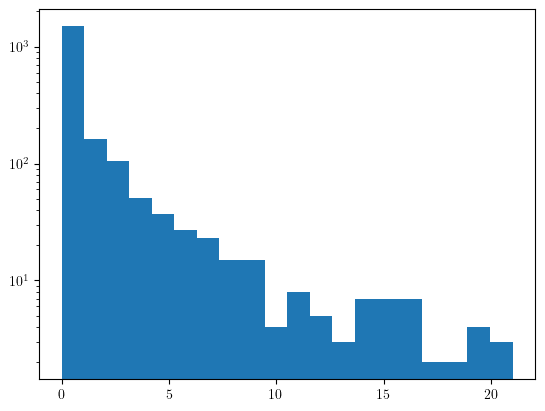

In [23]:
# params_repeated_all.shape
# delta_box_all_squeezed_all.shape
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all
pl.figure()
_ = pl.hist(Nhalos_truth_flatten_all, bins=20, range=(0, 21))
pl.yscale('log')
pl.show()


In [2]:




# vel_m_truth.shape, pos_m_truth.shape
def process_DMO_snaps(snap_fname, norm_delta = 100, norm_vel = 1000, BoxSize = 25., grid = 8, grid_sbox = 32, npart_test = 128**3):
    import numpy as np
    import h5py as h5
    import numpy as np
    import sys,os
    import readgadget
    import MAS_library as MASL
    import pickle as pk
    import readfof
    import matplotlib
    import h5py as h5
    import matplotlib.pyplot as pl
    pl.rc('text', usetex=True)
    # Palatino
    pl.rc('font', family='DejaVu Sans')
    from ngp_funcs import NGP_mass, NGP_xyz, NGP_xyzM, NGP_xyz_vxvyvz



    np.random.seed(0)
    # root = '/scratch/bdne/spandey3/camels_tng/DMO/CV'
    # # z = {4:0, -1: 99, 3:0.5}[snapnum]
    # # df = h5.File(f'{root}/CV_{isim_fid}/snapshot_090.hdf5', 'r')            
    df = h5.File(snap_fname, 'r')                
    pos = df['PartType1']['Coordinates'][()]/1000.
    vel = df['PartType1']['Velocities'][()]
    ids = np.arange(len(pos))
    # get random permutation of indices of particles:
    arg_rand_perm = np.random.permutation(len(pos))

    # npart_test = 128**3
    ind = arg_rand_perm[:npart_test]
    pos_m_truth = pos[ind]
    vel_m_truth = vel[ind]
    ids_m_truth = ids[ind]

    # npart_test = len(pos_m_truth)
    # pos_m_truth = pos
    # vel_m_truth = vel
    # ids_m_truth = ids


    # BoxSize = 25.
    # grid = 8
    # nMax_m = 32
    Npart = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_m_truth), Npart, BoxSize)

    nMax_h = 6000

    dfpart_ngp_wxyz_vxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 6)))
    NGP_xyz_vxvyvz(np.float32(pos_m_truth), np.float32(vel_m_truth), dfpart_ngp_wxyz_vxvyvz, BoxSize)

    # from tqdm import tqdm
          
    # norm_vel = 1000    
    # grid_sbox = 32
    MAS = 'NGP'
    verbose = False
    delta_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 6))
    # vel_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3))
    for j1 in (range(grid)):
        for j2 in range(grid):
            for j3 in range(grid):
                
                if j1 == 0:
                    jn1 = grid - 1
                else:
                    jn1 = j1 - 1
                if j1 == grid - 1:
                    jp1 = 0
                else:
                    jp1 = j1 + 1

                jp1_all = [jn1, j1, jp1]

                if j2 == 0:
                    jn2 = grid - 1
                else:
                    jn2 = j2 - 1

                if j2 == grid - 1:
                    jp2 = 0
                else:
                    jp2 = j2 + 1

                jp2_all = [jn2, j2, jp2]

                if j3 == 0:
                    jn3 = grid - 1
                else:
                    jn3 = j3 - 1

                if j3 == grid - 1:
                    jp3 = 0
                else:
                    jp3 = j3 + 1

                jp3_all = [jn3, j3, jp3]

                coord_add_sign = [-1,0,1]
                all_part = []
                all_part_vel = []
                for i1 in range(3):
                    for i2 in range(3):
                        for i3 in range(3):
                            all_part_here = dfpart_ngp_wxyz_vxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3],:,:3]
                            all_part_vel_here = dfpart_ngp_wxyz_vxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3],:,3:]
                            indpos = np.where(all_part_here[:,0] != 0)[0]
                            all_part_here = all_part_here[indpos,:]
                            all_part_vel_here = all_part_vel_here[indpos,:]
                            all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
                            all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
                            all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

                            if len(all_part) == 0:
                                all_part = all_part_here
                                all_part_vel = all_part_vel_here
                            else:
                                all_part = np.vstack((all_part, all_part_here))
                                all_part_vel = np.vstack((all_part_vel, all_part_vel_here))



                box_size_sbox = BoxSize/(2*grid)
                all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part0 = all_part[all_part0_sel]
                delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)
                nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox0 /= nbar0
                delta_sbox0 /= norm_delta

                pvel = all_part_vel[all_part0_sel]
                ppos = all_part0 + box_size_sbox
                rho_m_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(ppos, rho_m_orig, (2*box_size_sbox), 'CIC', verbose=False)
                mom_m_x_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)                
                MASL.MA(ppos, mom_m_x_orig, (2*box_size_sbox), 'CIC', verbose=False, W=pvel[:,0].astype(np.float32))
                mom_m_y_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)                
                MASL.MA(ppos, mom_m_y_orig, (2*box_size_sbox), 'CIC', verbose=False, W=pvel[:,1].astype(np.float32))
                mom_m_z_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)               
                MASL.MA(ppos, mom_m_z_orig, (2*box_size_sbox), 'CIC', verbose=False, W=pvel[:,2].astype(np.float32))                
                vel_m_x_orig = mom_m_x_orig/rho_m_orig
                vel_m_y_orig = mom_m_y_orig/rho_m_orig
                vel_m_z_orig = mom_m_z_orig/rho_m_orig
                # at voxels with non-finite values, set velocities to zero:
                vel_m_x_orig[~np.isfinite(vel_m_x_orig)] = 0.0
                vel_m_y_orig[~np.isfinite(vel_m_y_orig)] = 0.0
                vel_m_z_orig[~np.isfinite(vel_m_z_orig)] = 0.0
                # divide out by 1000.:
                vel_m_x_orig /= norm_vel
                vel_m_y_orig /= norm_vel
                vel_m_z_orig /= norm_vel

                box_size_sbox = 2*BoxSize/(2*grid)
                all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part1 = all_part[all_part1_sel]
                delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)
                nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox1 /= nbar1
                delta_sbox1 /= norm_delta


                box_size_sbox = 3*BoxSize/(2*grid)
                all_part2 = all_part
                delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)
                nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox2 /= nbar2
                delta_sbox2 /= norm_delta

                delta_sbox_all = np.stack((delta_sbox0, delta_sbox1, delta_sbox2, vel_m_x_orig, vel_m_y_orig, vel_m_z_orig))

                # move first axis to last:
                delta_sbox_all = np.moveaxis(delta_sbox_all, 0, -1)

                delta_box_all[j1,j2,j3] = delta_sbox_all

    delta_box_all_squeezed = np.reshape(delta_box_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 6))

    return delta_box_all_squeezed




# snap_array = np.array([90])
# for isim_fid in tqdm(isim_fid_array):
def process_LH_sim(isim_fid):
    import numpy as np
    import sys,os
    import readgadget
    import MAS_library as MASL
    import pickle as pk
    import readfof
    import matplotlib
    import h5py as h5
    import matplotlib.pyplot as pl
    pl.rc('text', usetex=True)
    # Palatino
    pl.rc('font', family='DejaVu Sans')
    from ngp_funcs import NGP_mass, NGP_xyz, NGP_xyzM, NGP_xyz_vxvyvz    
    nrand_sel_box = 512
    snapnum = 90
    # mass_type = 'rockstar_200c'
    # h5.File('/scratch/bdne/spandey3/camels_tng/caesar/CV/CV_12/caesar_newsnaps_090.hdf5','r') 
    snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/LH'
    snapdir = snap_dir_base + '/' + f'LH_{isim_fid}'  #folder hosting the catalogue
    group_catalog = f'{snapdir}/groups_090.hdf5'
    with h5.File(group_catalog, "r") as hf:
        M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.1)
        pos = hf['Subhalo/SubhaloPos'][:]/1000.


    Mstar_cut = 8
    indsel = np.where(M_star > Mstar_cut)[0]
    pos_h_truth = pos[indsel]
    prop_truth = M_star[indsel]
    prop_min = Mstar_cut
    prop_max = 11

    norm_delta = 100,
    norm_vel = 1000,
    BoxSize = 25.
    grid = 8
    grid_sbox = 32
    npart_test = 128**3
    nMax_h = 20
    nvocab = 64

    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
    savefname = f'{sdir}/subhalo_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_lgMmin_{Mstar_cut}.pkl'
    # check if the file already exists:
    if os.path.exists(savefname):
        print(f'File {savefname} already exists. Skipping...')
        return
    else:
        root = '/scratch/bdne/spandey3/camels_tng/DMO/LH'
        snapnums = [90, 84, 78, 70, 60]
        # z = {4:0, -1: 99, 3:0.5}[snapnum]
        delta_box_all_squeezed = []
        for snapnum in snapnums:
            print(isim_fid, snapnum)
            snap_fname = f'{root}/LH_{isim_fid}/snapshot_0{snapnum}.hdf5'
            delta_box_all_squeezed_js = process_DMO_snaps(snap_fname, norm_delta = norm_delta, norm_vel = norm_vel, BoxSize = BoxSize, grid = grid, grid_sbox = grid_sbox, npart_test = npart_test)
            if len(delta_box_all_squeezed) == 0:
                delta_box_all_squeezed = delta_box_all_squeezed_js
            else:
                delta_box_all_squeezed = np.concatenate((delta_box_all_squeezed, delta_box_all_squeezed_js), axis=-1)
            # print(delta_box_all_squeezed.shape)
        # elif grid == 128:
        # BoxSize = 25.
        # grid = 8
        # nMax_h = 42
        dfhalo_ngp_wxyzM = np.float32(np.zeros((grid, grid, grid, nMax_h, 4)))
        NGP_xyzM(np.float32(pos_h_truth), np.float32(prop_truth), dfhalo_ngp_wxyzM, BoxSize)


        # dfhalo_ngp_wxyzM_squeezed = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
        Nhalos_truth = np.float32(np.zeros((grid, grid, grid)))
        MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)

        prop_halos_argsort = np.flip(np.argsort(dfhalo_ngp_wxyzM[:,:,:,:,3], axis=-1), axis=-1)
        xmin = BoxSize/grid/2
        # lgMin = np.log10(Mmin_cut)
        # lgMax = 15.5
        dfhalo_ngp_xyzM_sorted_scaled = np.zeros_like(dfhalo_ngp_wxyzM)
        for i1 in range(grid):
            for i2 in range(grid):
                for i3 in range(grid):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 0] = dfhalo_ngp_wxyzM[i1, i2, i3, prop_halos_argsort[i1, i2, i3], 0]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 0] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, 0] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, 0] + xmin)/(2*xmin)

                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 1] = dfhalo_ngp_wxyzM[i1, i2, i3, prop_halos_argsort[i1, i2, i3], 1]
                    indpos_y = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 1] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_y, 1] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_y, 1] + xmin)/(2*xmin)

                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 2] = dfhalo_ngp_wxyzM[i1, i2, i3, prop_halos_argsort[i1, i2, i3], 2]
                    indpos_z = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 2] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_z, 2] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_z, 2] + xmin)/(2*xmin)

                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 3] = dfhalo_ngp_wxyzM[i1, i2, i3, prop_halos_argsort[i1, i2, i3], 3]
                    indpos_M = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 3] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 3] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 3] - prop_min)/(prop_max - prop_min)



        indzeros = np.where(dfhalo_ngp_xyzM_sorted_scaled == 0.0)
        dfhalo_ngp_xyzM_sorted_scaled[indzeros] = -1.0


        # np.amin(dfhalo_ngp_xyzM_sorted_scaled), np.amax(dfhalo_ngp_xyzM_sorted_scaled)
        # nvocab = 128
        
        bins_digitize = np.linspace(-1e-3, 1, nvocab)
        # bins_digitize.insert(0, -1)
        bins_digitize = np.insert(bins_digitize, 0, -1)
        # bins_digitize
        dfhalo_ngp_xyzM_sorted_scaled_digitized = np.digitize(dfhalo_ngp_xyzM_sorted_scaled, bins_digitize)

        start_token = 0
        pad_token = 1
        end_token = nvocab + 1
        space_token = nvocab + 2
        max_sentence_length = 1 + nMax_h*4 + 1 + (nMax_h-1)
        dfhalo_ngp_xyzM_tokenized = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int32) + end_token

        dfhalo_ngp_xyzM_tokenized[..., 0] = start_token
        # for jh in range(nMax_h):
        jh = 1
        while jh < 5*nMax_h:
            # if dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh, 0] > 1:
            dfhalo_ngp_xyzM_tokenized[..., jh + 0] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 3]
            dfhalo_ngp_xyzM_tokenized[..., jh + 1] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 0]
            dfhalo_ngp_xyzM_tokenized[..., jh + 2] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 1]
            dfhalo_ngp_xyzM_tokenized[..., jh + 3] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 2]
            if jh//5 < nMax_h - 1:
                dfhalo_ngp_xyzM_tokenized[..., jh + 4] = space_token
            # else:
            #     dfhalo_ngp_xyzM_tokenized[..., 1 + nMax_h*4] = end_token
            jh += 5



        dfhalo_ngp_xyzM_tokenized_padded_ended = np.copy(dfhalo_ngp_xyzM_tokenized)
        for i1 in range(grid):
            for i2 in range(grid):
                for i3 in range(grid):
                    ind1 = np.where(dfhalo_ngp_xyzM_tokenized[i1, i2, i3,:] == 1)[0]
                    try:
                        ind1 = ind1[0]
                        if ind1 == 1:
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1] = end_token
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1+1:] = pad_token
                        else:
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token
                    except:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                        # dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token



        dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended, (grid*grid*grid, max_sentence_length))
        # dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.shape

        dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
        Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))
        
        # rand_sel = np.sort(np.random.permutation(len(Nhalos_truth_flatten))[:nrand_sel_box])
        rand_sel = np.arange(nrand_sel_box)

        saved = {'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed':dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.astype(np.int16)[rand_sel,...],
                # 'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
                'Nhalos_truth_flatten': Nhalos_truth_flatten.astype(np.int16)[rand_sel],
                'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32)[rand_sel, ...],
                'rand_sel': rand_sel,
                'nvocab_total': nvocab + 3,
                'max_sentence_length': max_sentence_length,
                'grid': grid,
                'grid_sbox': grid_sbox,
                'nMax_h': nMax_h,
                'BoxSize': BoxSize,
                'prop_min': prop_min,
                'prop_max': prop_max,
                'xmin': xmin,
                'norm_delta': norm_delta,
                'norm_vel': norm_vel,
                'start_token': start_token,
                'pad_token': pad_token,
                'end_token': end_token,
                'space_token': space_token
                }
        pk.dump(saved, open(savefname, 'wb'))
        return






In [3]:
for ji in range(990, 1000):
    print(ji)
    process_LH_sim(ji)





990
990 90


/tmp/ipykernel_2754426/18516279.py:145: RuntimeWarning: invalid value encountered in divide
  vel_m_x_orig = mom_m_x_orig/rho_m_orig
/tmp/ipykernel_2754426/18516279.py:146: RuntimeWarning: invalid value encountered in divide
  vel_m_y_orig = mom_m_y_orig/rho_m_orig
/tmp/ipykernel_2754426/18516279.py:147: RuntimeWarning: invalid value encountered in divide
  vel_m_z_orig = mom_m_z_orig/rho_m_orig


990 84
990 78
990 70
990 60
991
991 90
991 84
991 78
991 70
991 60
992
992 90
992 84
992 78
992 70
992 60
993
993 90
993 84
993 78
993 70
993 60
994
994 90
994 84
994 78
994 70
994 60
995
995 90
995 84
995 78
995 70
995 60
996
996 90
996 84
996 78
996 70
996 60
997
997 90
997 84
997 78
997 70
997 60
998
998 90
998 84
998 78
998 70
998 60
999
999 90
999 84
999 78
999 70
999 60
